In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib 
import os

C:\Users\Luis\AppData\Roaming\Python\Python38\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [7]:
os.chdir('C:/Users/Luis/Box/R15 Sensor Preprocessing and Analysis/JPCS Special Issue') #set directory for desktop
#os.chdir('/Users/sandoval/Library/CloudStorage/Box-Box/R15 Sensor Preprocessing and Analysis/JPCS Special Issue') #this is for when i use my mac instead of my desktop
raw = pd.read_csv('Full Summary Features 7.24.2025.csv') #filtered summary data from madison

FileNotFoundError: [Errno 2] No such file or directory: 'Full Summary Features 7.24.2025.csv'

In [3]:
#i want to see all the columns so i can specifically pick the features i actually want
    #we are going to make a dataset containing just restrict alongside predictors aka physio
    #then we are going to make another dataset containing just urge to restrict alongside physio
    #we don't want to include any other EMA in our train/test data for each analysis

for col in raw.columns: 
    print(col) 

Unnamed..0
Time
HR_Mean
HR_Minimum
HR_Maximum
HR_Stdev
HR_RMS
HR_MAD
HR_MAV
HR_Median
HR_P25
HR_P75
EDA_Mean
EDA_Minimum
EDA_Maximum
EDA_Stdev
EDA_RMS
EDA_MAD
EDA_MAV
EDA_Median
EDA_P25
EDA_P75
TEMP_Mean
TEMP_Minimum
TEMP_Maximum
TEMP_Stdev
TEMP_RMS
TEMP_MAD
TEMP_MAV
TEMP_Median
TEMP_P25
TEMP_P75
meanCenteredEDA_Mean
meanCenteredEDA_Minimum
meanCenteredEDA_Maximum
meanCenteredEDA_Stdev
meanCenteredEDA_RMS
meanCenteredEDA_MAD
meanCenteredEDA_MAV
meanCenteredEDA_Median
meanCenteredEDA_P25
meanCenteredEDA_P75
meanCenteredHR_Mean
meanCenteredHR_Minimum
meanCenteredHR_Maximum
meanCenteredHR_Stdev
meanCenteredHR_RMS
meanCenteredHR_MAD
meanCenteredHR_MAV
meanCenteredHR_Median
meanCenteredHR_P25
meanCenteredHR_P75
meanCenteredTEMP_Mean
meanCenteredTEMP_Minimum
meanCenteredTEMP_Maximum
meanCenteredTEMP_Stdev
meanCenteredTEMP_RMS
meanCenteredTEMP_MAD
meanCenteredTEMP_MAV
meanCenteredTEMP_Median
meanCenteredTEMP_P25
meanCenteredTEMP_P75
ethica_time
lag
tdif
cumsumT
ethica_time_utc
dayvar
beepvar


In [4]:
#descriptives for paper

raw['restrict'].mean()
raw['restrict'].min()
raw['restrict'].max()
raw['restrict'].std()

34.06041654648963

In [5]:
raw['urge_restrict'].mean()
raw['urge_restrict'].min()
raw['urge_restrict'].max()
raw['urge_restrict'].std()

31.124504242823576

In [6]:
#row_nan_count = .isna().sum(axis=1)

raw["urge_restrict"].isna().sum() #71 urge_restrict points missing 
raw["restrict"].isna().sum() #54 restrict items missing
len(raw["urge_restrict"])
raw

,Unnamed..0,Time,HR_Mean,HR_Minimum,HR_Maximum,HR_Stdev,HR_RMS,HR_MAD,HR_MAV,HR_Median,...,socialanx_medCentered,sens_body_meanCentered,sens_body_medCentered,ridthoughts_meanCentered,ridthoughts_medCentered,memories_meanCentered,memories_medCentered,chewspit_meanCentered,chewspit_medCentered,PR
0,117,58:00.0,93.129563,66.83,120.20,14.947826,94.321047,13.171499,120.20,94.55,...,21.0,0.279661,-1.0,13.211864,3.0,10.110169,-0.5,0.0,0.0,PR003
1,116,28:00.0,67.698626,56.77,85.90,6.844791,68.043630,5.718079,85.90,67.03,...,22.0,3.279661,2.0,7.211864,-3.0,-58.889831,-69.5,0.0,0.0,PR003
2,115,56:00.0,70.553065,55.93,93.38,9.837114,71.235269,7.708571,93.38,68.85,...,0.0,-1.720339,-3.0,12.211864,2.0,-58.889831,-69.5,0.0,0.0,PR003
3,114,56:00.0,90.937768,57.98,149.50,25.878040,94.546664,23.029055,149.50,84.10,...,0.0,-2.720339,-4.0,3.211864,-7.0,9.110169,-1.5,0.0,0.0,PR003
4,113,25:00.0,74.612836,57.92,93.05,10.477028,75.344527,8.849632,93.05,75.70,...,0.0,1.279661,0.0,17.211864,7.0,9.110169,-1.5,0.0,0.0,PR003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1825,3,18:00.0,89.603111,67.65,105.58,11.408228,90.326137,9.806514,105.58,93.92,...,0.0,-15.258427,-16.0,10.022472,8.0,-1.314607,0.0,0.0,0.0,PR128
1826,4,14:00.0,86.490337,71.97,105.58,10.494469,87.124431,9.454118,105.58,84.92,...,0.0,-15.258427,-16.0,10.022472,8.0,-1.314607,0.0,0.0,0.0,PR128
1827,2,27:00.0,81.366835,59.48,111.25,10.247335,82.009304,8.262121,111.25,78.70,...,0.0,-15.258427,-16.0,-12.977528,-15.0,-1.314607,0.0,0.0,0.0,PR128
1828,1,53:00.0,123.766039,83.67,200.65,29.368184,127.201272,23.482926,200.65,116.10,...,0.0,-15.258427,-16.0,-12.977528,-15.0,-1.314607,0.0,0.0,0.0,PR128


In [7]:
#random seed. I picked 6 because I like 6 and i always pick 6. this is so we get the same results every time
np.random.seed(6)

In [8]:
corrs = raw.filter(['meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev',  
                    'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median',
                    'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                    'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD',
                    'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75',
                    'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev',
                    'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median',
                    'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'urge_restrict', 'restrict'])

In [9]:
corrs = corrs.rename(columns={"meanCenteredEDA_Mean" : "EDA_Mean",
                      "meanCenteredEDA_Minimum" : "EDA_Minimum",
                      "meanCenteredEDA_Maximum" : "EDA_Maximum",
                      "meanCenteredEDA_Stdev" : "EDA_Stdev",
                      "meanCenteredEDA_RMS" : "EDA_RMS",
                      "meanCenteredEDA_MAD" : "EDA_MAD",
                      "meanCenteredEDA_MAV" : "EDA_MAV",
                      "meanCenteredEDA_Median" : "EDA_Median",
                      "meanCenteredEDA_P25" : "EDA_P25",
                      "meanCenteredEDA_P75" : "EDA_P75",
                      "meanCenteredHR_Mean" : "HR_Mean",
                      "meanCenteredHR_Minimum" : "HR_Minimum",
                      "meanCenteredHR_Maximum" : "HR_Maximum",
                      "meanCenteredHR_Stdev" : "HR_Stdev",
                      "meanCenteredHR_RMS" : "HR_RMS",
                      "meanCenteredHR_MAD" : "HR_MAD",
                      "meanCenteredHR_MAV" : "HR_MAV",
                      "meanCenteredHR_Median" : "HR_Median",
                      "meanCenteredHR_P25" : "HR_P25",
                      "meanCenteredHR_P75" : "HR_P75",
                      "meanCenteredTEMP_Mean" : "TEMP_Mean",
                      "meanCenteredTEMP_Minimum" : "TEM_Minimum",
                      "meanCenteredTEMP_Maximum" : "TEMP_Maximum",
                      "meanCenteredTEMP_Stdev" : "TEMP_Stdev",
                      "meanCenteredTEMP_RMS" : "TEMP_RMS",
                      "meanCenteredTEMP_MAD" : "TEMP_MAD",
                      "meanCenteredTEMP_MAV" : "TEMP_MAV",
                      "meanCenteredTEMP_Median" : "TEMP_Median",
                      "meanCenteredTEMP_P25" : "TEMP_P25",
                      "meanCenteredTEMP_P75" : "TEMP_P75",
                      "urge_restrict" : "urge_restrict",
                      "restrict" : "restrict"})

In [10]:
Corr_Matrix = round(corrs.corr(),2)
print(Corr_Matrix)

               EDA_Mean  EDA_Minimum  EDA_Maximum  EDA_Stdev  EDA_RMS  \
EDA_Mean           1.00         0.86         0.93       0.69     0.92   
EDA_Minimum        0.86         1.00         0.65       0.28     0.70   
EDA_Maximum        0.93         0.65         1.00       0.89     0.92   
EDA_Stdev          0.69         0.28         0.89       1.00     0.77   
EDA_RMS            0.92         0.70         0.92       0.77     1.00   
EDA_MAD            0.69         0.28         0.88       1.00     0.76   
EDA_MAV            0.88         0.58         0.97       0.90     0.96   
EDA_Median         1.00         0.88         0.90       0.65     0.91   
EDA_P25            0.98         0.93         0.85       0.54     0.87   
EDA_P75            0.99         0.80         0.95       0.76     0.93   
HR_Mean            0.11         0.07         0.12       0.11     0.16   
HR_Minimum         0.11         0.07         0.13       0.11     0.16   
HR_Maximum         0.07         0.05         0.08  

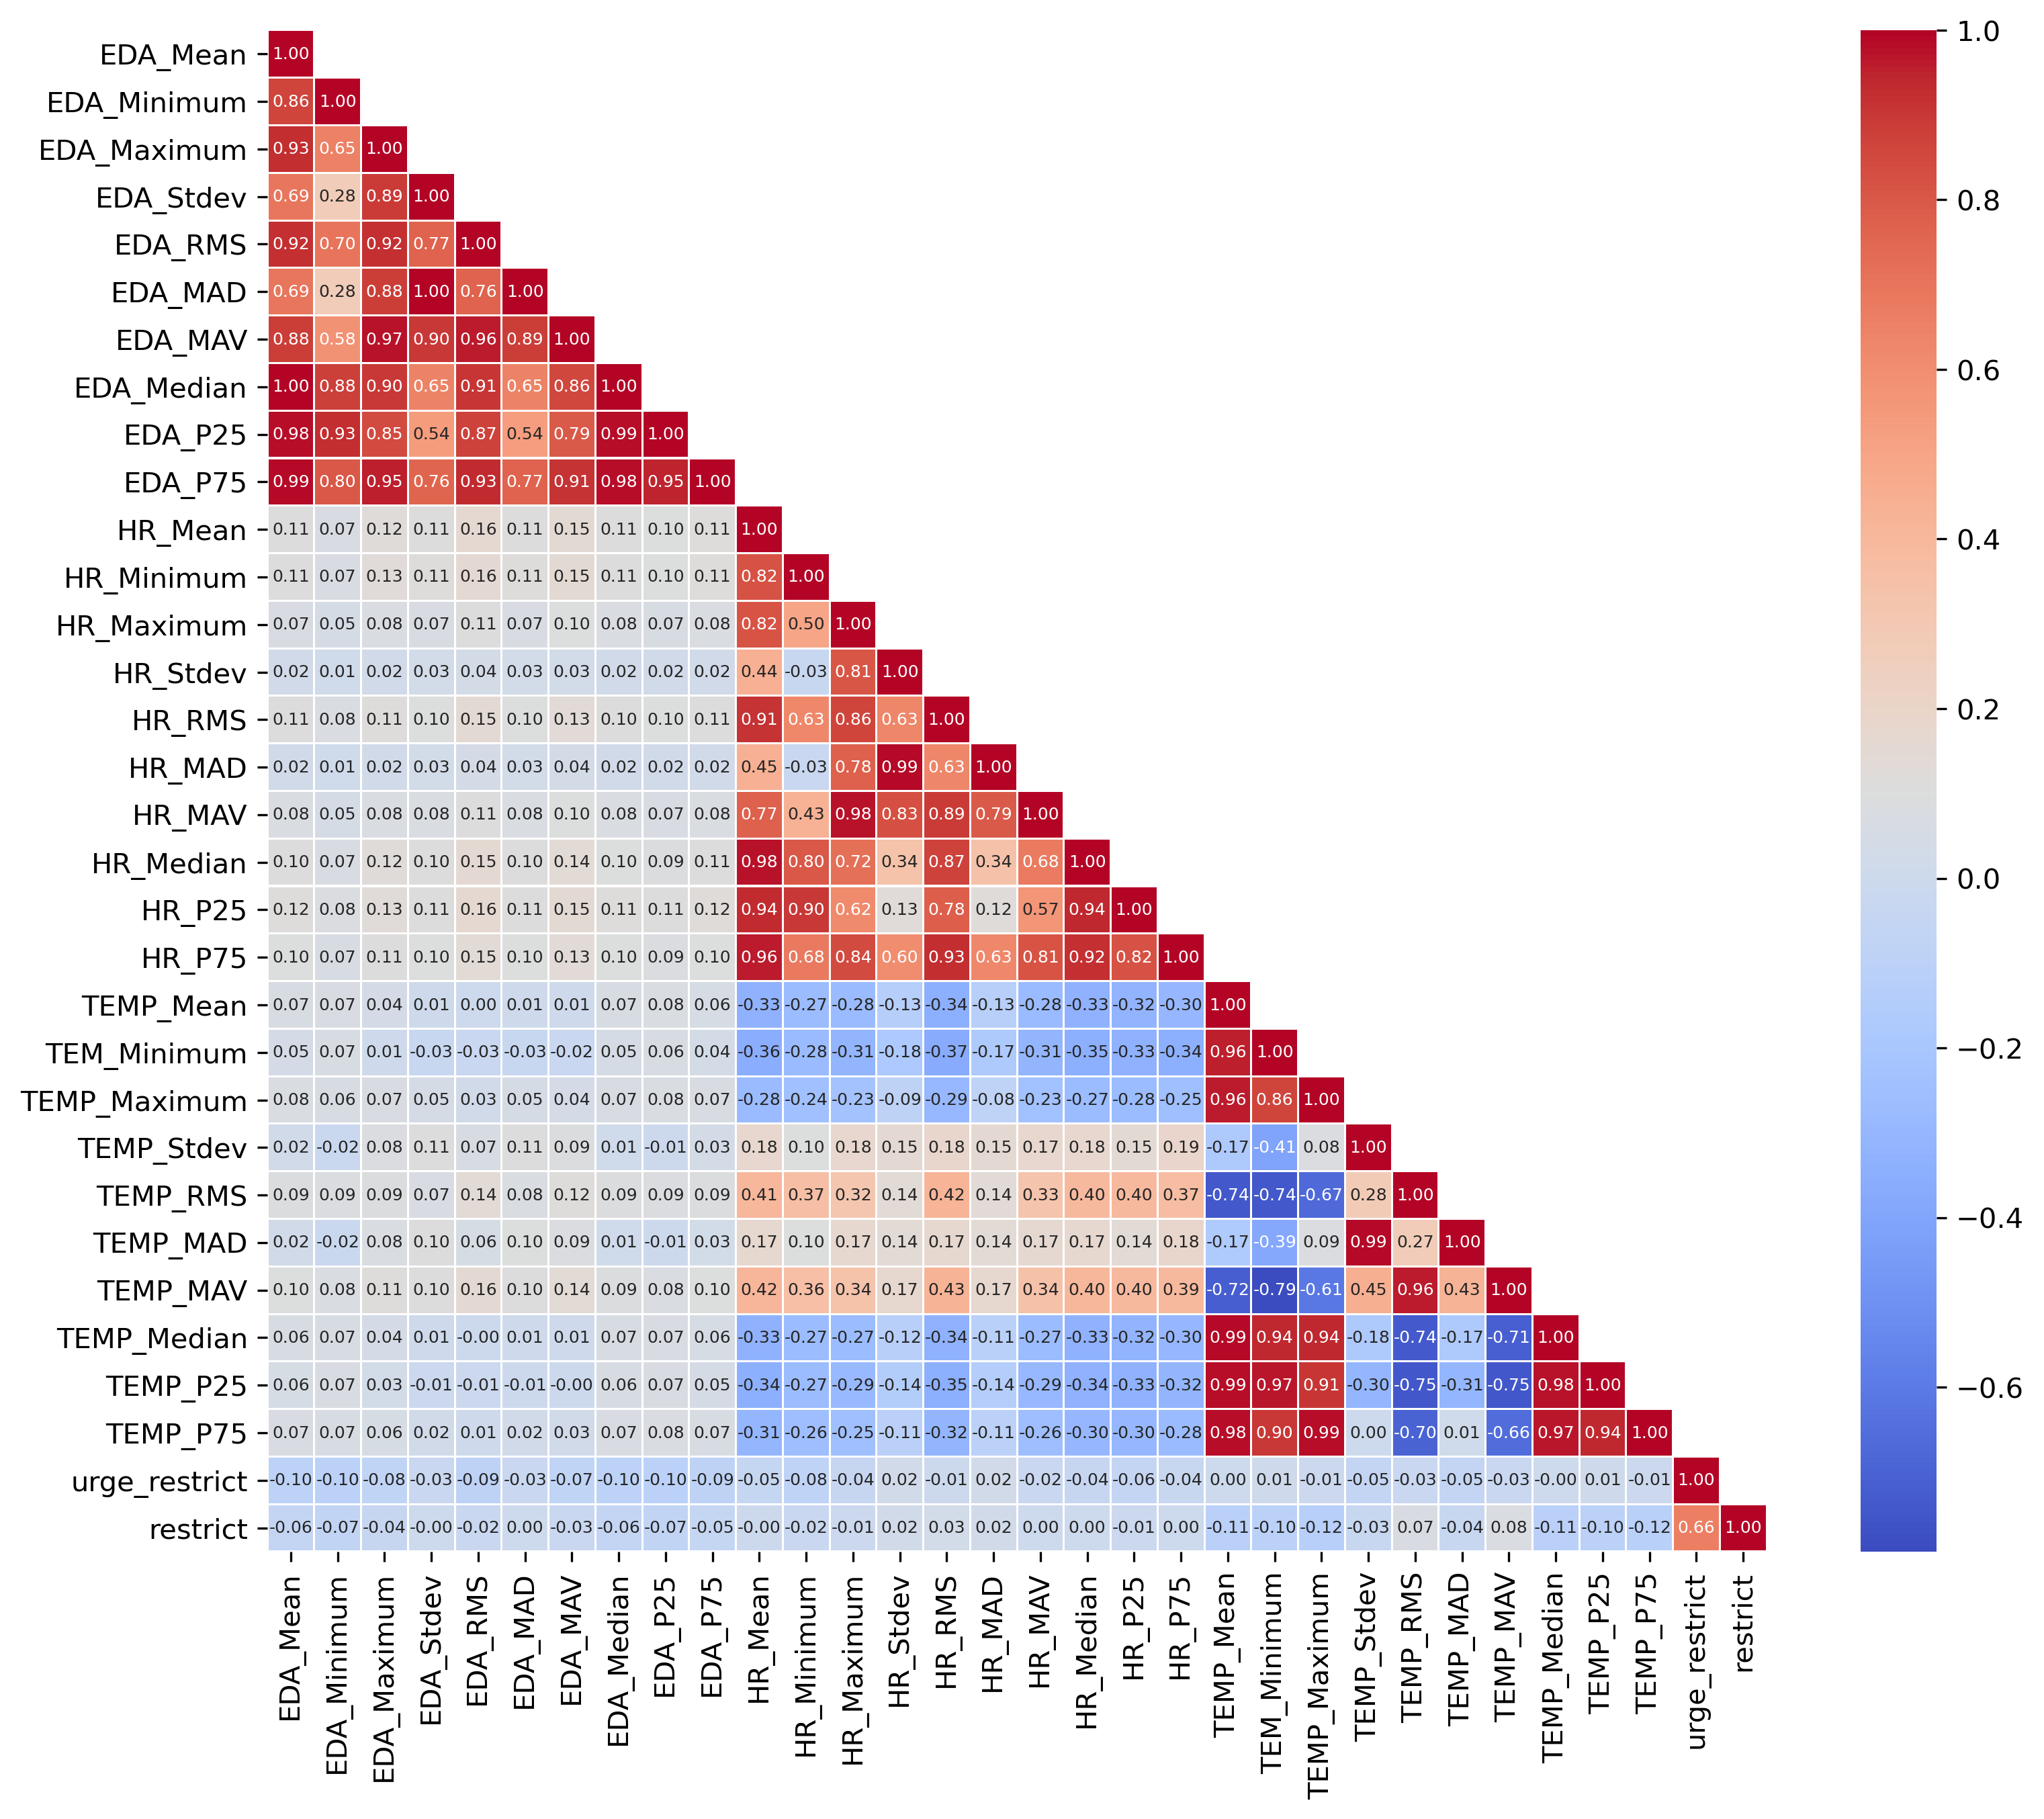

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_full = corrs.corr()

mask = np.zeros_like(correlation_full, dtype=bool)
mask[np.triu_indices_from(mask)] = True
np.fill_diagonal(mask, False)
 
plt.figure(figsize=(12,10), dpi =300)
sns.heatmap(correlation_full,fmt=".2f", linewidth=.5, cmap = 'coolwarm', mask = mask, annot=True,annot_kws={"fontsize": 6})
plt.show()

In [12]:
#creating the dataset for predicting urge_restrict from physio alone
urgeData = raw.filter(['ethica_time', 'meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'urge_restrict'])

urgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(urgeData['urge_restrict'])) #check that NAs exist - if false, we are good

False

In [13]:
#creating the dataset for predicting restrict from physio alone
restrictData = raw.filter(['ethica_time', 'meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'restrict'])

restrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(restrictData['restrict'])) #check that NAs exist - if false, we are good

False

In [1]:
restrictData

NameError: name 'restrictData' is not defined

In [14]:
import time
import datetime

urgeData.set_index('ethica_time', inplace=True)
urgeData.index = pd.to_datetime(urgeData.index, format='%m/%d/%Y %H:%M')
urgeData.sort_index(inplace=True)

restrictData.set_index('ethica_time', inplace=True)
restrictData.index = pd.to_datetime(restrictData.index, format='%m/%d/%Y %H:%M')
restrictData.sort_index(inplace=True)

In [15]:
urgeData

,meanCenteredEDA_Mean,meanCenteredEDA_Minimum,meanCenteredEDA_Maximum,meanCenteredEDA_Stdev,meanCenteredEDA_RMS,meanCenteredEDA_MAD,meanCenteredEDA_MAV,meanCenteredEDA_Median,meanCenteredEDA_P25,meanCenteredEDA_P75,...,meanCenteredTEMP_Minimum,meanCenteredTEMP_Maximum,meanCenteredTEMP_Stdev,meanCenteredTEMP_RMS,meanCenteredTEMP_MAD,meanCenteredTEMP_MAV,meanCenteredTEMP_Median,meanCenteredTEMP_P25,meanCenteredTEMP_P75,urge_restrict
ethica_time,,,,,,,,,,,,,,,,,,,,,
2020-10-13 10:15:00,-0.190639,-0.239242,-0.065096,0.015592,0.191275,0.012140,0.239242,-0.188023,-0.203389,-0.181620,...,-1.830127,-1.330127,0.112603,1.629448,0.094291,1.830127,-1.630127,-1.720127,-1.540127,100.0
2020-10-13 11:48:00,-0.205330,-0.241803,-0.081743,0.029270,0.207405,0.022240,0.241803,-0.207230,-0.230279,-0.190584,...,-3.040127,-1.830127,0.207486,2.536516,0.149786,3.040127,-2.540127,-2.630127,-2.430127,100.0
2020-10-13 17:01:00,-0.200530,-0.239243,-0.158587,0.018513,0.201383,0.015301,0.239243,-0.205956,-0.212357,-0.186752,...,-0.950127,-0.040127,0.221902,0.506970,0.189345,0.950127,-0.390127,-0.670127,-0.310127,63.0
2020-10-13 19:16:00,-0.207698,-0.241803,-0.196994,0.007797,0.207844,0.006298,0.241803,-0.205956,-0.212357,-0.200835,...,-5.050127,-4.590127,0.128472,4.831768,0.109122,5.050127,-4.830127,-4.950127,-4.750127,17.0
2020-10-14 09:21:00,0.434005,-0.114684,1.046271,0.243350,0.497549,0.199459,1.046271,0.406817,0.254339,0.609268,...,-1.350127,-0.510127,0.217514,0.920908,0.173030,1.350127,-0.890127,-1.010127,-0.720127,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-04-03 10:10:00,-0.598831,-0.660232,-0.402669,0.051629,0.601052,0.040175,0.660232,-0.614101,-0.637167,-0.574378,...,-2.516220,-0.706220,0.347563,1.197428,0.291081,2.516220,-1.116220,-1.386220,-0.796220,72.0
2022-04-03 12:51:00,-0.533191,-0.651262,-0.352694,0.048815,0.535420,0.043158,0.651262,-0.532091,-0.575659,-0.485960,...,-1.276220,-1.076220,0.044732,1.184803,0.038847,1.276220,-1.176220,-1.216220,-1.136220,75.0
2022-04-03 16:17:00,0.428406,-0.673046,3.385366,0.557996,0.703393,0.455729,3.385366,0.288346,-0.040976,0.934474,...,0.523780,1.003780,0.117048,0.790804,0.089015,1.003780,0.783780,0.723780,0.843780,75.0


In [16]:
restrictData

,meanCenteredEDA_Mean,meanCenteredEDA_Minimum,meanCenteredEDA_Maximum,meanCenteredEDA_Stdev,meanCenteredEDA_RMS,meanCenteredEDA_MAD,meanCenteredEDA_MAV,meanCenteredEDA_Median,meanCenteredEDA_P25,meanCenteredEDA_P75,...,meanCenteredTEMP_Minimum,meanCenteredTEMP_Maximum,meanCenteredTEMP_Stdev,meanCenteredTEMP_RMS,meanCenteredTEMP_MAD,meanCenteredTEMP_MAV,meanCenteredTEMP_Median,meanCenteredTEMP_P25,meanCenteredTEMP_P75,restrict
ethica_time,,,,,,,,,,,,,,,,,,,,,
2020-10-13 10:15:00,-0.190639,-0.239242,-0.065096,0.015592,0.191275,0.012140,0.239242,-0.188023,-0.203389,-0.181620,...,-1.830127,-1.330127,0.112603,1.629448,0.094291,1.830127,-1.630127,-1.720127,-1.540127,82.0
2020-10-13 11:48:00,-0.205330,-0.241803,-0.081743,0.029270,0.207405,0.022240,0.241803,-0.207230,-0.230279,-0.190584,...,-3.040127,-1.830127,0.207486,2.536516,0.149786,3.040127,-2.540127,-2.630127,-2.430127,100.0
2020-10-13 17:01:00,-0.200530,-0.239243,-0.158587,0.018513,0.201383,0.015301,0.239243,-0.205956,-0.212357,-0.186752,...,-0.950127,-0.040127,0.221902,0.506970,0.189345,0.950127,-0.390127,-0.670127,-0.310127,100.0
2020-10-13 19:16:00,-0.207698,-0.241803,-0.196994,0.007797,0.207844,0.006298,0.241803,-0.205956,-0.212357,-0.200835,...,-5.050127,-4.590127,0.128472,4.831768,0.109122,5.050127,-4.830127,-4.950127,-4.750127,100.0
2020-10-14 09:21:00,0.434005,-0.114684,1.046271,0.243350,0.497549,0.199459,1.046271,0.406817,0.254339,0.609268,...,-1.350127,-0.510127,0.217514,0.920908,0.173030,1.350127,-0.890127,-1.010127,-0.720127,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-04-03 10:10:00,-0.598831,-0.660232,-0.402669,0.051629,0.601052,0.040175,0.660232,-0.614101,-0.637167,-0.574378,...,-2.516220,-0.706220,0.347563,1.197428,0.291081,2.516220,-1.116220,-1.386220,-0.796220,75.0
2022-04-03 12:51:00,-0.533191,-0.651262,-0.352694,0.048815,0.535420,0.043158,0.651262,-0.532091,-0.575659,-0.485960,...,-1.276220,-1.076220,0.044732,1.184803,0.038847,1.276220,-1.176220,-1.216220,-1.136220,55.0
2022-04-03 16:17:00,0.428406,-0.673046,3.385366,0.557996,0.703393,0.455729,3.385366,0.288346,-0.040976,0.934474,...,0.523780,1.003780,0.117048,0.790804,0.089015,1.003780,0.783780,0.723780,0.843780,41.0


In [17]:
#now what i want to do is reserve a portion of the data to test after the fact - the remaining data we'll do k-fold grid search cross validation
#we're going to split the data as follows: 
#80% of the data is going to be the train/test data for the model
#the remaining 20% will be held and we will use the trained/tested model to see how closely it predicts the 20% holdover set

urgeX = urgeData.drop(columns = {'urge_restrict'}) #drop urge_restrict from dataframe for the splitting
urgey = urgeData.filter(['urge_restrict']) #make a dataframe containing only urge_restrict variable

restX = restrictData.drop(columns = {'restrict'})
resty = restrictData.filter(['restrict'])

#urgeX_train, urgeX_test, urgey_train, urgey_test = TimeSeriesSplit(urgeX, urgey, random_state=6,test_size=0.20) 
#restX_train, restX_test, resty_train, resty_test = TimeSeriesSplit(restX, resty, random_state=6,test_size=0.20) 
#we're sticking with 6 for random_state
#the test sets are what we are going to validate our models on later

In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from numpy import arange

#we're going to start exclusively with the urge data for now, we'll circle back to the restrict data later 

urgeMod = ElasticNet(max_iter = 1000) 
cv = TimeSeriesSplit(n_splits=5) #i still like 6, we're doing a 10-fold cross-validation repeating 3 times

In [19]:
from numpy import mean
from numpy import std
from numpy import absolute

#developing a grid search cross-validation function that will provide us with a dictionary that contains the hyperparameters
#the dictionary with hyperparameters will allow us to automatically plug in our best hyperparameters 
def cross_validation(model, _X, _y, _cv):
    param_grid = {'alpha'     : [0.1,1,10,0.01],
                'l1_ratio'  :  np.arange(0.40,1.00,0.10),
                'tol'       : [0.0001,0.001] }
    _scoring = ['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2']
    grid_search = GridSearchCV(estimator = model, param_grid = param_grid, cv = _cv, scoring = _scoring, return_train_score = True, refit= 'neg_root_mean_squared_error', n_jobs = -1)
    grid_search.fit(X = _X, y = _y,)
    d = dict()
    d['results'] = pd.DataFrame(grid_search.cv_results_)
    alpha = format(grid_search.best_params_).partition("{'alpha': ")[2] #alpha parameter
    d['alpha'] = alpha.partition(",")[0]
    l1 = format(grid_search.best_params_).partition("'l1_ratio': ")[2] #L1 ratio parameter
    d['l1'] = l1.partition(",")[0]
    tol = format(grid_search.best_params_).partition("'tol': ")[2] #tolerance parameter
    d['tol'] = tol.partition("}")[0]
    ind = format(grid_search.best_index_) #best index - this will be used to find our associated test R2
    d['ind'] = ind
    print("Best parameters : {}".format(grid_search.best_params_))
    return d
           

In [20]:
urgecv_result = cross_validation(urgeMod, urgeX, urgey, cv) #this does the cross validation

Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.001}


In [21]:
for train_index, test_index in cv.split(urgeX):
    urgeX_train, urgeX_test = urgeX.iloc[train_index, :], urgeX.iloc[test_index,:]
    urgey_train, urgey_test = urgey.iloc[train_index], urgey.iloc[test_index]

In [22]:
### now we build the final model for urge - we are using the optimal hyperparameters divulged through the grid search 
### to fit a final model and then test it on the hold-out test set
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error as mae 
from sklearn.metrics import mean_squared_error as mse
from math import sqrt

urgeModTuned = ElasticNet(alpha = float(urgecv_result['alpha']), l1_ratio = float(urgecv_result['l1']), tol = float(urgecv_result['tol']), max_iter = 1000).fit(urgeX_train,urgey_train)
urgeyPred = urgeModTuned.predict(urgeX_test)
print('MAE = ' + str(mae(urgey_test,urgeyPred))) #out of sample (OOS) MAE = 25.84
print('R2 = ' + str(r2_score(urgey_test,urgeyPred))) #OOS R2 = -.64
print('RMSE = ' + str(sqrt(mse(urgey_test,urgeyPred)))) # RMSE = 29.13

MAE = 25.837466208406518
R2 = -0.6435043315472952
RMSE = 29.13148644724299


In [23]:
restMod = ElasticNet(max_iter = 1000) 
restcv_result = cross_validation(restMod, restX, resty, cv) #this does the cross validation

Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.001}


In [24]:
for train_index, test_index in cv.split(urgeX):
    restX_train, restX_test = restX.iloc[train_index, :], restX.iloc[test_index,:]
    resty_train, resty_test = resty.iloc[train_index], resty.iloc[test_index]

In [25]:
restModTuned = ElasticNet(alpha = float(restcv_result['alpha']), l1_ratio = float(restcv_result['l1']), tol = float(restcv_result['tol']), max_iter = 1000).fit(restX_train,resty_train)
restyPred = restModTuned.predict(restX_test)
print('MAE = ' + str(mae(resty_test,restyPred))) #out of sample (OOS) MAE = 33.08
print('R2 = ' + str(r2_score(resty_test,restyPred))) #OOS R2 = -1.67
print('RMSE = ' + str(sqrt(mse(resty_test,restyPred)))) # RMSE = 36.08

MAE = 33.11061360820837
R2 = -1.6524359109801492
RMSE = 35.92993199849995


In [26]:
#we're gonna try with diagnoses now 

diag = pd.read_csv('ScreeningsR15-EDDiagnosticsSummary_DATA_2024-02-25_1408.csv') #dataframe containing diagnoses by ID
diag["PR"] = diag['record_id_73f3b8'] #making a column to match IDs
diag = diag.filter(['PR', 'currentdx1_ade7bc']) #i want to only merge the current general diagnoses and keep the ID variable
diagRaw = diag.merge(raw, how = 'inner', on = 'PR') #we made it 

diagRaw.head()

,PR,currentdx1_ade7bc,Unnamed..0,Time,HR_Mean,HR_Minimum,HR_Maximum,HR_Stdev,HR_RMS,HR_MAD,...,socialanx_meanCentered,socialanx_medCentered,sens_body_meanCentered,sens_body_medCentered,ridthoughts_meanCentered,ridthoughts_medCentered,memories_meanCentered,memories_medCentered,chewspit_meanCentered,chewspit_medCentered
0,PR003,1.0,117,58:00.0,93.129563,66.83,120.20,14.947826,94.321047,13.171499,...,9.483051,21.0,0.279661,-1.0,13.211864,3.0,10.110169,-0.5,0.0,0.0
1,PR003,1.0,116,28:00.0,67.698626,56.77,85.90,6.844791,68.043630,5.718079,...,10.483051,22.0,3.279661,2.0,7.211864,-3.0,-58.889831,-69.5,0.0,0.0
2,PR003,1.0,115,56:00.0,70.553065,55.93,93.38,9.837114,71.235269,7.708571,...,-11.516949,0.0,-1.720339,-3.0,12.211864,2.0,-58.889831,-69.5,0.0,0.0
3,PR003,1.0,114,56:00.0,90.937768,57.98,149.50,25.878040,94.546664,23.029055,...,-11.516949,0.0,-2.720339,-4.0,3.211864,-7.0,9.110169,-1.5,0.0,0.0
4,PR003,1.0,113,25:00.0,74.612836,57.92,93.05,10.477028,75.344527,8.849632,...,-11.516949,0.0,1.279661,0.0,17.211864,7.0,9.110169,-1.5,0.0,0.0


In [27]:
pd.set_option("display.max.rows", None)
idiographicDx = diagRaw[["PR","currentdx1_ade7bc"]]
idiographicDx.drop_duplicates(keep='first')

#coding values: 1 = AN, 2 = BN, 3 = BED, 4 = OSFED... there should  be no BED cases. 
#we will look at AN and BN specifically for now
bnmask = diagRaw['currentdx1_ade7bc'].values == 2
bn = diagRaw.loc[bnmask]

anmask = diagRaw['currentdx1_ade7bc'].values == 1
an = diagRaw.loc[anmask]

osfedmask = diagRaw['currentdx1_ade7bc'].values == 4
osfed = diagRaw.loc[osfedmask]

restrictFilter = raw.groupby('PR').mean('restrict') # anyone with a mean restriction endorsement >= 40 for this analysis
restrictMask = restrictFilter['restrict'].values >= 40
restrictOnly = restrictFilter.loc[restrictMask]
restrictOnly = restrictOnly.rename_axis('PR').reset_index()
restIdList = restrictOnly['PR'].copy()

urgeMask = restrictFilter['urge_restrict'].values >= 40
urgeOnly = restrictFilter.loc[urgeMask]
urgeOnly = urgeOnly.rename_axis('PR').reset_index()
urgeIdList = urgeOnly['PR'].copy()

In [28]:
restIdList = restIdList.tolist()
urgeIdList = urgeIdList.tolist()

idList = restIdList + urgeIdList
idList = set(idList)
idList

{'PR003',
 'PR008',
 'PR011',
 'PR018',
 'PR021',
 'PR022',
 'PR023',
 'PR025',
 'PR030',
 'PR032',
 'PR033',
 'PR037',
 'PR038',
 'PR044',
 'PR078',
 'PR079',
 'PR084',
 'PR085',
 'PR086',
 'PR101',
 'PR102',
 'PR104',
 'PR113',
 'PR116',
 'PR117',
 'PR126',
 'PR128'}

In [29]:
restrictData = raw.loc[raw["PR"].isin(idList)]
len(restrictData['PR'].unique()) #27 cases in restriction analysis

27

In [30]:
restrictData['restrict'].mean() #65.31
restrictData['restrict'].min() #0
restrictData['restrict'].max() #100
restrictData['restrict'].std() #24.21

24.21243115212654

In [31]:
restrictData['urge_restrict'].mean() #64.61
restrictData['urge_restrict'].min() #0
restrictData['urge_restrict'].max() #100
restrictData['urge_restrict'].std() #24.41

24.411365533965434

In [32]:
restrictUrgeData = restrictData.filter(['ethica_time', 'meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'urge_restrict'])

restrictRestrictData = restrictData.filter(['ethica_time', 'meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'restrict'])

In [33]:
restrictUrgeData.set_index('ethica_time', inplace=True)
restrictUrgeData.index = pd.to_datetime(restrictUrgeData.index, format='%m/%d/%Y %H:%M')
restrictUrgeData.sort_index(inplace=True)

restrictRestrictData.set_index('ethica_time', inplace=True)
restrictRestrictData.index = pd.to_datetime(restrictRestrictData.index, format='%m/%d/%Y %H:%M')
restrictRestrictData.sort_index(inplace=True)

In [34]:
restrictUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(restrictUrgeData['urge_restrict'])) #check that NAs exist - if false, we are good

restrictRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(restrictRestrictData['restrict']))#check that NAs exist - if false, we are good

False

In [35]:
restUrgeX = restrictUrgeData.drop(columns = {'urge_restrict'}) #drop urge_restrict from dataframe for the splitting
restUrgey = restrictUrgeData.filter(['urge_restrict']) #make a dataframe containing only urge_restrict variable

restRestX = restrictRestrictData.drop(columns = {'restrict'})
restResty = restrictRestrictData.filter(['restrict'])

In [36]:
restUrgeMod = ElasticNet(max_iter = 1000) 
restUrgecv_result = cross_validation(restUrgeMod, restUrgeX, restUrgey, cv) #this does the cross validation

Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.001}


In [37]:
for train_index, test_index in cv.split(restUrgeX):
    restUrgeX_train, restUrgeX_test = restUrgeX.iloc[train_index, :], restUrgeX.iloc[test_index,:]
    restUrgey_train, restUrgey_test = restUrgey.iloc[train_index], restUrgey.iloc[test_index]

In [38]:
restUrgeModTuned = ElasticNet(alpha = float(restUrgecv_result['alpha']), l1_ratio = float(restUrgecv_result['l1']), tol = float(restUrgecv_result['tol']), max_iter = 1000).fit(restUrgeX_train,restUrgey_train)
restUrgeyPred = restUrgeModTuned.predict(restUrgeX_test)
print('MAE = ' + str(mae(restUrgey_test,restUrgeyPred))) #out of sample (OOS) MAE = 15.16
print('R2 = ' + str(r2_score(restUrgey_test,restUrgeyPred))) #OOS R2 = -0.05
print('RMSE = ' + str(sqrt(mse(restUrgey_test,restUrgeyPred)))) # RMSE = 19.15

MAE = 15.156951116494527
R2 = -0.04515547151571497
RMSE = 19.15538409837689


In [39]:
#predicting restrict item in Restriction sample
restRestMod = ElasticNet(max_iter = 1000) 
restRestcv_result = cross_validation(restRestMod, restRestX, restResty, cv) #this does the cross validation

Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.0001}


In [40]:
for train_index, test_index in cv.split(restRestX):
    restRestX_train, restRestX_test = restRestX.iloc[train_index, :], restRestX.iloc[test_index,:]
    restResty_train, restResty_test = restResty.iloc[train_index], restResty.iloc[test_index]

In [41]:
restRestModTuned = ElasticNet(alpha = float(restRestcv_result['alpha']), l1_ratio = float(restRestcv_result['l1']), tol = float(restRestcv_result['tol']), max_iter = 1000).fit(restRestX_train,restResty_train)
restRestyPred = restRestModTuned.predict(restRestX_test)
print('MAE = ' + str(mae(restResty_test,restRestyPred))) #out of sample (OOS) MAE = 18.76
print('R2 = ' + str(r2_score(restResty_test,restRestyPred))) #OOS R2 = -0.50
print('RMSE = ' + str(sqrt(mse(restResty_test,restRestyPred)))) # RMSE = 21.51

MAE = 18.230112874935823
R2 = -0.3988636630949218
RMSE = 20.79167947998527


In [71]:
#BN subsets
bnUrgeData = bn.filter(['ethica_time', 'meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'urge_restrict'])

bnRestrictData = bn.filter(['ethica_time', 'meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'restrict'])

bnUrgeData.set_index('ethica_time', inplace=True)
bnUrgeData.index = pd.to_datetime(bnUrgeData.index, format='%m/%d/%Y %H:%M')
bnUrgeData.sort_index(inplace=True)

bnRestrictData.set_index('ethica_time', inplace=True)
bnRestrictData.index = pd.to_datetime(bnRestrictData.index, format='%m/%d/%Y %H:%M')
bnRestrictData.sort_index(inplace=True)

bnUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(bnUrgeData['urge_restrict'])) #check that NAs exist - if false, we are good

bnRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(bnRestrictData['restrict']))#check that NAs exist - if false, we are good

#AN subsets
anUrgeData = an.filter(['ethica_time', 'meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'urge_restrict'])

anRestrictData = an.filter(['ethica_time', 'meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'restrict'])

anUrgeData.set_index('ethica_time', inplace=True)
anUrgeData.index = pd.to_datetime(anUrgeData.index, format='%m/%d/%Y %H:%M')
anUrgeData.sort_index(inplace=True)

anRestrictData.set_index('ethica_time', inplace=True)
anRestrictData.index = pd.to_datetime(anRestrictData.index, format='%m/%d/%Y %H:%M')
anRestrictData.sort_index(inplace=True)

anUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(anUrgeData['urge_restrict'])) #check that NAs exist - if false, we are good

anRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(anRestrictData['restrict']))#check that NAs exist - if false, we are good

#OSFED subsets
osfedUrgeData = osfed.filter(['ethica_time', 'meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'urge_restrict'])

osfedRestrictData = osfed.filter(['ethica_time', 'meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'restrict'])

osfedUrgeData.set_index('ethica_time', inplace=True)
osfedUrgeData.index = pd.to_datetime(osfedUrgeData.index, format='%m/%d/%Y %H:%M')
osfedUrgeData.sort_index(inplace=True)

osfedRestrictData.set_index('ethica_time', inplace=True)
osfedRestrictData.index = pd.to_datetime(osfedRestrictData.index, format='%m/%d/%Y %H:%M')
osfedRestrictData.sort_index(inplace=True)

osfedUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(osfedUrgeData['urge_restrict'])) #check that NAs exist - if false, we are good

osfedRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(osfedRestrictData['restrict']))#check that NAs exist - if false, we are good

False

In [72]:
bnUrgeX = bnUrgeData.drop(columns = {'urge_restrict'}) #drop urge_restrict from dataframe for the splitting
bnUrgey = bnUrgeData.filter(['urge_restrict']) #make a dataframe containing only urge_restrict variable

bnRestX = bnRestrictData.drop(columns = {'restrict'})
bnResty = bnRestrictData.filter(['restrict'])

anUrgeX = anUrgeData.drop(columns = {'urge_restrict'}) #drop urge_restrict from dataframe for the splitting
anUrgey = anUrgeData.filter(['urge_restrict']) #make a dataframe containing only urge_restrict variable

anRestX = anRestrictData.drop(columns = {'restrict'})
anResty = anRestrictData.filter(['restrict'])

osfedUrgeX = osfedUrgeData.drop(columns = {'urge_restrict'}) #drop urge_restrict from dataframe for the splitting
osfedUrgey = osfedUrgeData.filter(['urge_restrict']) #make a dataframe containing only urge_restrict variable

osfedRestX = osfedRestrictData.drop(columns = {'restrict'})
osfedResty = osfedRestrictData.filter(['restrict'])

In [44]:
#ANALYSIS FOR BN
bnUrgeMod = ElasticNet(max_iter = 1000) 
bnUrgecv_result = cross_validation(bnUrgeMod, bnUrgeX, bnUrgey, cv) #this does the cross validation

Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.001}


In [45]:
for train_index, test_index in cv.split(bnUrgeX):
    bnUrgeX_train, bnUrgeX_test = bnUrgeX.iloc[train_index, :], bnUrgeX.iloc[test_index,:]
    bnUrgey_train, bnUrgey_test = bnUrgey.iloc[train_index], bnUrgey.iloc[test_index]

In [67]:
bnUrgeModTuned = ElasticNet(alpha = float(bnUrgecv_result['alpha']), l1_ratio = float(bnUrgecv_result['l1']), tol = float(bnUrgecv_result['tol']), max_iter = 1000).fit(bnUrgeX_train,bnUrgey_train)
bnUrgeyPred = bnUrgeModTuned.predict(bnUrgeX_test)
print('MAE = ' + str(mae(bnUrgey_test,bnUrgeyPred))) #out of sample (OOS) MAE = 38.84
print('R2 = ' + str(r2_score(bnUrgey_test,bnUrgeyPred))) #OOS R2 = -1.38
print('RMSE = ' + str(sqrt(mse(bnUrgey_test,bnUrgeyPred)))) # RMSE = 43.70

MAE = 38.836412299251165
R2 = -1.3824129654316963
RMSE = 43.700102996763704


In [47]:
bnRestMod = ElasticNet(max_iter = 1000) 
bnRestcv_result = cross_validation(bnRestMod, bnRestX, bnResty, cv) #this does the cross validation

Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.0001}


In [48]:
for train_index, test_index in cv.split(bnRestX):
    bnRestX_train, bnRestX_test = bnRestX.iloc[train_index, :], bnRestX.iloc[test_index,:]
    bnResty_train, bnResty_test = bnResty.iloc[train_index], bnResty.iloc[test_index]

In [49]:
bnRestModTuned = ElasticNet(alpha = float(bnRestcv_result['alpha']), l1_ratio = float(bnRestcv_result['l1']), tol = float(bnRestcv_result['tol']), max_iter = 1000).fit(bnRestX_train,bnResty_train)
bnRestyPred = bnRestModTuned.predict(bnRestX_test)
print('MAE = ' + str(mae(bnResty_test,bnRestyPred))) #out of sample (OOS) MAE = 30.02
print('R2 = ' + str(r2_score(bnResty_test,bnRestyPred))) #OOS R2 = -1.32
print('RMSE = ' + str(sqrt(mse(bnResty_test,bnRestyPred)))) # RMSE = 38.01

MAE = 30.228710051474856
R2 = -1.3521678229747773
RMSE = 38.24003005440801


In [50]:
#ANALYSIS FOR AN
anUrgeMod = ElasticNet(max_iter = 1000) 
anUrgecv_result = cross_validation(anUrgeMod, anUrgeX, anUrgey, cv) #this does the cross validation

Best parameters : {'alpha': 10, 'l1_ratio': 0.5, 'tol': 0.0001}


In [51]:
for train_index, test_index in cv.split(anUrgeX):
    anUrgeX_train, anUrgeX_test = anUrgeX.iloc[train_index, :], anUrgeX.iloc[test_index,:]
    anUrgey_train, anUrgey_test = anUrgey.iloc[train_index], anUrgey.iloc[test_index]

In [52]:
anUrgeModTuned = ElasticNet(alpha = float(anUrgecv_result['alpha']), l1_ratio = float(anUrgecv_result['l1']), tol = float(anUrgecv_result['tol']), max_iter = 1000).fit(anUrgeX_train,anUrgey_train)
anUrgeyPred = anUrgeModTuned.predict(anUrgeX_test)
print('MAE = ' + str(mae(anUrgey_test,anUrgeyPred))) #out of sample (OOS) MAE = 33.89
print('R2 = ' + str(r2_score(anUrgey_test,anUrgeyPred))) #OOS R2 = -1.92
print('RMSE = ' + str(sqrt(mse(anUrgey_test,anUrgeyPred)))) # RMSE = 36.78

MAE = 33.93223233610098
R2 = -1.9216775175403908
RMSE = 36.79580135836443


In [53]:
anRestMod = ElasticNet(max_iter = 1000) 
anRestcv_result = cross_validation(anRestMod, anRestX, anResty, cv) #this does the cross validation

Best parameters : {'alpha': 10, 'l1_ratio': 0.4, 'tol': 0.001}


In [54]:
for train_index, test_index in cv.split(anRestX):
    anRestX_train, anRestX_test = anRestX.iloc[train_index, :], anRestX.iloc[test_index,:]
    anResty_train, anResty_test = anResty.iloc[train_index], anResty.iloc[test_index]

In [55]:
anRestModTuned = ElasticNet(alpha = float(anRestcv_result['alpha']), l1_ratio = float(anRestcv_result['l1']), tol = float(anRestcv_result['tol']), max_iter = 1000).fit(anRestX_train,anResty_train)
anRestyPred = anRestModTuned.predict(anRestX_test)
print('MAE = ' + str(mae(anResty_test,anRestyPred))) #out of sample (OOS) MAE = 41.43
print('R2 = ' + str(r2_score(anResty_test,anRestyPred))) #OOS R2 = -4.24
print('RMSE = ' + str(sqrt(mse(anResty_test,anRestyPred)))) # RMSE = 44.47

MAE = 41.4342072480916
R2 = -4.243563929788978
RMSE = 44.47108094506711


In [74]:
#ANALYSIS FOR OSFED
osfedUrgeMod = ElasticNet(max_iter = 1000) 
osfedUrgecv_result = cross_validation(osfedUrgeMod, osfedUrgeX, osfedUrgey, cv) #this does the cross validation

Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.0001}


In [75]:
for train_index, test_index in cv.split(osfedUrgeX):
    osfedUrgeX_train, osfedUrgeX_test = osfedUrgeX.iloc[train_index, :], osfedUrgeX.iloc[test_index,:]
    osfedUrgey_train, osfedUrgey_test = osfedUrgey.iloc[train_index], osfedUrgey.iloc[test_index]

In [76]:
osfedUrgeModTuned = ElasticNet(alpha = float(osfedUrgecv_result['alpha']), l1_ratio = float(osfedUrgecv_result['l1']), tol = float(osfedUrgecv_result['tol']), max_iter = 1000).fit(osfedUrgeX_train,osfedUrgey_train)
osfedUrgeyPred = osfedUrgeModTuned.predict(osfedUrgeX_test)
print('MAE = ' + str(mae(osfedUrgey_test,osfedUrgeyPred))) #out of sample (OOS) MAE = 17.05
print('R2 = ' + str(r2_score(osfedUrgey_test,osfedUrgeyPred))) #OOS R2 = -0.09
print('RMSE = ' + str(sqrt(mse(osfedUrgey_test,osfedUrgeyPred)))) # RMSE = 23.72

MAE = 17.05244193832671
R2 = -0.08570963595012104
RMSE = 23.71738402961059


In [77]:
osfedRestMod = ElasticNet(max_iter = 1000) 
osfedRestcv_result = cross_validation(osfedRestMod, osfedRestX, osfedResty, cv) #this does the cross validation

Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.0001}


In [78]:
for train_index, test_index in cv.split(osfedRestX):
    osfedRestX_train, osfedRestX_test = osfedRestX.iloc[train_index, :], osfedRestX.iloc[test_index,:]
    osfedResty_train, osfedResty_test = osfedResty.iloc[train_index], osfedResty.iloc[test_index]

In [79]:
osfedRestModTuned = ElasticNet(alpha = float(osfedRestcv_result['alpha']), l1_ratio = float(osfedRestcv_result['l1']), tol = float(osfedRestcv_result['tol']), max_iter = 1000).fit(osfedRestX_train,osfedResty_train)
osfedRestyPred = osfedRestModTuned.predict(osfedRestX_test)
print('MAE = ' + str(mae(osfedResty_test,osfedRestyPred))) #out of sample (OOS) MAE = 30.02
print('R2 = ' + str(r2_score(osfedResty_test,osfedRestyPred))) #OOS R2 = -1.32
print('RMSE = ' + str(sqrt(mse(osfedResty_test,osfedRestyPred)))) # RMSE = 38.00

MAE = 24.05008545495226
R2 = -0.18983060613604463
RMSE = 28.83357683502798


In [62]:
#need the dataset to include participant IDS for the idiographic analyses
urgeDatawid = raw.filter(['ethica_time', 'meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'urge_restrict', 'PR'])

restrictDatawid = raw.filter(['ethica_time', 'meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'restrict', 'PR'])

urgeDatawid.set_index('ethica_time', inplace=True)
urgeDatawid.index = pd.to_datetime(urgeDatawid.index, format='%m/%d/%Y %H:%M')
urgeDatawid.sort_index(inplace=True)

restrictDatawid.set_index('ethica_time', inplace=True)
restrictDatawid.index = pd.to_datetime(restrictDatawid.index, format='%m/%d/%Y %H:%M')
restrictDatawid.sort_index(inplace=True)

urgeDatawid.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(urgeDatawid['urge_restrict'])) #check that NAs exist - if false, we are good

restrictDatawid.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(restrictDatawid['restrict']))#check that NAs exist - if false, we are good

False

In [63]:
idDescriptives = urgeDatawid.groupby("PR", as_index = False).agg(
                      {'urge_restrict':['mean', 'std']})
idDescriptives

PR urge_restrict           
                   mean        std
0   PR003     82.439655  10.342221
1   PR008     44.030303  42.203161
2   PR010      1.354839   5.001956
3   PR011     46.403361  20.773728
4   PR018     69.133333   9.101544
5   PR020     29.780702  19.956927
6   PR021     55.500000  33.110421
7   PR022     81.000000        NaN
8   PR023     47.324324  22.378132
9   PR025     59.346535  10.410990
10  PR030     50.692308  11.884055
11  PR032     91.238095   5.830155
12  PR033     79.129032  16.485836
13  PR037     53.138614  20.990012
14  PR038     66.944444  12.873072
15  PR039     15.253521  15.271559
16  PR042     22.250000  20.471402
17  PR044     29.944444  16.874876
18  PR048     16.591549  18.636046
19  PR073     10.379310  27.423157
20  PR078     36.347826   9.023246
21  PR079     40.965517  16.764083
22  PR084     85.333333   4.676181
23  PR085     72.461538  15.570353
24  PR086     53.277778  23.007789
25  PR096     38.363636  34.791587
26  PR101     79.736842  12.339724
27  PR102     90.571429   3.807526
28  PR104     93.529412   9.388275
29  PR106      7.000000   2.549510
30  PR113     73.400000   2.880972
31  PR115      7.900000   7.866243
32  PR116     71.733333  13.688875
33  PR117     33.636364  19.412742
34  PR126     78.416667  14.417077
35  PR128     56.300000  15.674983

In [64]:
idDescriptivesRest = restrictDatawid.groupby("PR", as_index = False).agg(
                      {'restrict':['mean', 'std']})
idDescriptivesRest

PR   restrict           
                mean        std
0   PR003  84.543103   6.960000
1   PR008  80.333333  17.049551
2   PR010   1.107692   3.976977
3   PR011  77.672269   6.320681
4   PR018  29.533333  24.482841
5   PR020   0.114035   0.606145
6   PR021  71.666667  26.755685
7   PR022  84.000000        NaN
8   PR023  48.324324  22.905669
9   PR025  63.413462  12.243176
10  PR030  24.153846  11.795805
11  PR032  37.047619  25.200612
12  PR033  79.151515  18.513713
13  PR037  42.267327  16.819567
14  PR038  58.967391  13.766060
15  PR039   1.397260   3.196090
16  PR042  10.290000  11.008991
17  PR044  79.611111   6.222718
18  PR048  19.194444  21.400697
19  PR073   1.896552   5.531370
20  PR078  47.565217   5.719394
21  PR079  21.740741  14.007121
22  PR084  85.500000   3.271085
23  PR085  58.538462  12.210756
24  PR086  28.216216  19.861348
25  PR096  36.272727  34.670134
26  PR101  72.666667  17.100567
27  PR102  89.396226   5.617455
28  PR104  78.882353  15.695869
29  PR106  15.600000  20.935616
30  PR113  59.600000  12.641202
31  PR115   2.800000   2.699794
32  PR116  80.650000  13.294353
33  PR117  76.545455  28.977107
34  PR126  80.625000  10.994797
35  PR128  56.700000  14.518603

In [65]:
useMod = ElasticNet(max_iter = 1000) 

PRList = list(urgeDatawid['PR'].unique())
resultsUrgeList = []
resultsRestrictList = []
for PR in PRList:
    curUrgeData = urgeDatawid[urgeDatawid['PR'] == PR]
    curRestrictData = restrictDatawid[restrictDatawid['PR'] == PR]
    curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
    curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
    if (len(curUrgeData) < 10 ) or (len(curRestrictData) <10) : # Don't use participants with fewer than 10 observations
        print('Skipping ' + PR + ' due to lack of data')
    else:
        urgeX = curUrgeData.drop(columns = {'urge_restrict','PR'})
        urgeY = curUrgeData.filter(['urge_restrict'])
        restrictX = curRestrictData.drop(columns = {'restrict','PR'})
        restrictY = curRestrictData.filter(['restrict'])
        
        print(PR + " urge")
        urgecv_result = cross_validation(useMod, urgeX, urgeY, cv)
        for train_index, test_index in cv.split(urgeX):
            urgeX_train, urgeX_test = urgeX.iloc[train_index, :], urgeX.iloc[test_index,:]
            urgeY_train, urgeY_test = urgeY.iloc[train_index], urgeY.iloc[test_index]     
        urgeModTuned = ElasticNet(alpha = float(urgecv_result['alpha']), l1_ratio = float(urgecv_result['l1']), tol = float(urgecv_result['tol']), max_iter = 1000).fit(urgeX_train,urgeY_train)
        urgeYPred = urgeModTuned.predict(urgeX_test)
        meanAbsEr = mae(urgeY_test,urgeYPred)
        r2 = r2_score(urgeY_test,urgeYPred)
        rmse = sqrt(mse(urgeY_test,urgeYPred))
        print('MAE = ' + str(meanAbsEr)) 
        print('R2 = ' + str(r2)) 
        print('RMSE = ' + str(rmse)) 
        urgecv_result['PR'] = PR
        urgecv_result['Size'] = len(curUrgeData)
        output = [PR, meanAbsEr, r2, rmse, len(curUrgeData)]
        resultsUrgeList.append(output)
        
        print(PR + " restrict")
        restrictcv_result = cross_validation(useMod, restrictX, restrictY, cv)
        for train_index, test_index in cv.split(restrictX):
            restrictX_train, restrictX_test = restrictX.iloc[train_index, :], restrictX.iloc[test_index,:]
            restrictY_train, restrictY_test = restrictY.iloc[train_index], restrictY.iloc[test_index]     
        restrictModTuned = ElasticNet(alpha = float(restrictcv_result['alpha']), l1_ratio = float(restrictcv_result['l1']), tol = float(restrictcv_result['tol']), max_iter = 1000).fit(restrictX_train,restrictY_train)
        restrictYPred = restrictModTuned.predict(restrictX_test)
        meanAbsEr = mae(restrictY_test,restrictYPred)
        r2 = r2_score(restrictY_test,restrictYPred)
        rmse = sqrt(mse(restrictY_test,restrictYPred))
        print('MAE = ' + str(meanAbsEr)) 
        print('R2 = ' + str(r2)) 
        print('RMSE = ' + str(rmse)) 
        restrictcv_result['PR'] = PR
        restrictcv_result['Size'] = len(curRestrictData)
        output = [PR, meanAbsEr, r2, rmse, len(curRestrictData)]
        resultsRestrictList.append(output)
        

PR008 urge


<ipython-input-65-596b4fc77361>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
<ipython-input-65-596b4fc77361>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing


Best parameters : {'alpha': 10, 'l1_ratio': 0.4, 'tol': 0.001}
MAE = 39.550229301827386
R2 = -0.10028912388680888
RMSE = 44.024582205580174
PR008 restrict
Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.0001}
MAE = 15.612185197711597
R2 = -0.5502326589843187
RMSE = 23.904679346894397
PR011 urge


<ipython-input-65-596b4fc77361>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
<ipython-input-65-596b4fc77361>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing


Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.001}
MAE = 15.75159310841577
R2 = -2.908722080204142
RMSE = 18.36095238669173
PR011 restrict
Best parameters : {'alpha': 1, 'l1_ratio': 0.7999999999999999, 'tol': 0.0001}
MAE = 4.394874715376711
R2 = -0.2893247581070506
RMSE = 5.277389827348622
PR003 urge


...

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:979: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
C:\Users\Luis\anaconda3\lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
<ipython-input-65-596b4fc77361>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
<ipython-input-65-596b4fc77361>:10: SettingWithCopyWarning: 
A value is 

Best parameters : {'alpha': 10, 'l1_ratio': 0.6, 'tol': 0.0001}
MAE = 7.316350315523966
R2 = nan
RMSE = 7.316350315523966
PR117 urge


C:\Users\Luis\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:979: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
C:\Users\Luis\anaconda3\lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Best parameters : {'alpha': 10, 'l1_ratio': 0.7, 'tol': 0.0001}
MAE = 35.52843692172861
R2 = nan
RMSE = 35.52843692172861
PR117 restrict
Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.0001}
MAE = 10.295655290297411
R2 = nan
RMSE = 10.295655290297411
Skipping PR113 due to lack of data


C:\Users\Luis\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:979: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
C:\Users\Luis\anaconda3\lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
<ipython-input-65-596b4fc77361>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
<ipython-input-65-596b4fc77361>:10: SettingWithCopyWarning: 
A value is 

In [89]:
resultsUrgeList

,0,1,2,3,4
0,PR008,39.550229,-0.100289,44.024582,66
1,PR011,15.751593,-2.908722,18.360952,119
2,PR003,4.425225,-0.055808,5.677656,116
3,PR018,4.804672,-0.160825,6.464494,15
4,PR020,23.733840,-1.694658,26.218010,114
5,PR010,1.539591,0.000000,1.890227,62
6,PR025,6.444700,-0.596080,8.474880,101
7,PR023,21.217305,-0.162142,22.227728,37
8,PR032,6.218187,-0.122467,6.442700,42
9,PR033,8.780612,-11.078588,10.857579,31


In [100]:
resultsUrgeList = pd.DataFrame(resultsUrgeList)
resultsUrgeList = resultsUrgeList.rename(columns = {0 : 'Participant ID', 1 : 'MAE', 2 : 'R2', 3 : 'RMSE', 4 : 'n'})
resultsUrgeList.to_csv("IdiographicUrge.csv")

In [101]:
resultsRestrictList = pd.DataFrame(resultsRestrictList)
resultsRestrictList = resultsRestrictList.rename(columns = {0 : 'Participant ID', 1 : 'MAE', 2 : 'R2', 3 : 'RMSE', 4 : 'n'})
resultsRestrictList.to_csv("IdiographicRestrict.csv")